# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs) 
3. sapphire.run(parameters) 

### This demo is for the CCA cluster 'rusty' which hosts the large test FIRE-2 and TNG tree files.

In [1]:
import sapphire 

In [3]:
%%prun -s cumulative # I am including this optional magic function so at the end ipynb will print code profiling/timing details

# first we will run on 5 subvolumes of TNG100 
parameters = {'output_path':'/mnt/ceph/users/vpandya/test_sapphire/', # name of output file, NOTE: this will be rewritten as a directory location, and our I/O module will take care writing
              'tree_type':'tng', # type of trees -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/', # either directory containing tree files or path to single tree file itself in case of TNG experimentation
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':['0_0_0','0_0_1','0_0_2','0_0_3','0_0_4'],
              'num_readers':5,
              'num_writers':5,
              'min_root_mass':1e10, # relevant for TNG, not for FIRE
              'parameter_functions':'fire2', # name of module in parameter_functions with fitting functions for free parameters
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'Rturb_transition':7.0, # time in Gyr where Rturb logistic function drops to ~half its max value
              'Rturb_slope':2.0, # exponential slope for smoothness/abruptness of Rturb logistic transition
              'f_supp':1.0, # multiply vturb in tff,eff by this to get more turb pressure support for a given vturb
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'Rturb_type':'RvirLogistic', # either Rvir so Rturb(t)=Rvir(t), or fiducial Rvir-->Rmax logistic from Pandya+22
              'verbose':False, # whether to print values of several properties at each timestep of integration (for debugging)
              'return_all':False} # False for initial solve_ivp call; will be re-run with True to store ALL properties for output 

sapphire.run(parameters)

# this took me 32 min on rusty with a single node with 128 cores (rome nodes)
# ~15 min of that is reading the huge tree files and ~13 min is writing outputs; only 5 min is actually spent on evolving the halos
# this speed will improve when I write a fast custom tree reader, use more efficient data structures, and do parallel writing

Parsing input parameters...
Reading trees...
Reading in trees for subvolume=0_0_1Reading in trees for subvolume=0_0_0Reading in trees for subvolume=0_0_4Reading in trees for subvolume=0_0_2Reading in trees for subvolume=0_0_3




Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_4.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_2.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_1.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Addit

Loading tree roots: 100%|██████████| 5944878712/5944878712 [00:16<00:00, 354363464.65it/s]


Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: inv

<!----- WARNING: solve_ivp exited with error for halo_name=1123173629


...

/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s


<!----- WARNING: solve_ivp exited with error for halo_name=1124045859


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # er

Writing results for subvolume=0_0_0
Writing results for subvolume=0_0_1
Writing results for subvolume=0_0_2
Writing results for subvolume=0_0_3
Writing results for subvolume=0_0_4
Finished writing output files to /mnt/ceph/users/vpandya/test_sapphire/
Finished -- thank you for using sapphire!
 

         5563179 function calls (5523114 primitive calls) in 1975.994 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   1153/1    0.004    0.000 1975.996 1975.996 {built-in method builtins.exec}
        1    7.870    7.870 1975.996 1975.996 <string>:1(<module>)
        1    0.001    0.001 1968.123 1968.123 driver.py:22(run)
      287    0.001    0.000 1174.632    4.093 threading.py:582(wait)
      286    0.002    0.000 1174.630    4.107 threading.py:288(wait)
     2000 1174.630    0.587 1174.630    0.587 {method 'acquire' of '_thread.lock' objects}
        2    0.000    0.000 1174.531  587.266 pool.py:359(map)
        2    0.000    0.000 1174.531  587.266 pool.py:764(get)
        2    0.000    0.000 1174.531  587.266 pool.py:761(wait)
        1    0.000    0.000  953.394  953.394 read_tng.py:90(read_trees)
78937/78555    0.048    0.000  786.145    0.010 {built-in method numpy.core._multiarray_umath.implement_array_functi

In [3]:
%%prun -s cumulative

### Now let's update the parameters dict to re-run on raw FIRE-2 trees (so using *net* DM accretion rates via finite differencing Mvir time series)
# we only need to update a few of the dict keys since the other stuff stays the same (and/or will not be used for this tree_type, e.g., subvolumes)
# we will run on all 12 core FIRE-2 halos by default, but if we wanted to do specific ones we could update the halo_names list 

parameters['tree_type'] = 'fire2'
parameters['tree_path'] = '/mnt/ceph/users/vpandya/trees_fire/'

sapphire.run(parameters)

# this took me 3 min of which 2.8 min was spent on reading the huge tree files

Parsing input parameters...
Reading trees...
Reading in tree for m10qReading in tree for m11bReading in tree for m10zReading in tree for m10yReading in tree for m11a




Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/vpandya/trees_fire/tree_m11a.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)
Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/vpandya/trees_fire/tree_m10z.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)
Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/vpandya/trees_fire/tree_m11b.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)
Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/

Loading tree roots: 100%|██████████| 966289540/966289540 [00:03<00:00, 242891236.89it/s]]
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:45: RuntimeWarning: divide by zero encountered in log10
  logMhires = np.log10(tree['Mvir_hires']) # z=0 Mvir counting only high-res DM particles
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:45: RuntimeWarning: divide by zero encountered in log10
  logMhires = np.log10(tree['Mvir_hires']) # z=0 Mvir counting only high-res DM particles
Loading tree roots: 100%|██████████| 1295526402/1295526402 [00:05<00:00, 222688870.32it/s]
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:46: RuntimeWarning: divide by zero encountered in log10
  logMlowres = np.log10(tree['Mvir_lowres']) # z=0 Mvir counting only low-res DM particles
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:45: RuntimeWarning: divide by zero encountered in log10
  logMhires = np.log10(tree['Mvir_hires']) # z=0 Mvir co

Reading in tree for m11c


Loading tree roots:   0%|          | 25099913/5096556135 [00:00<01:10, 72240947.81it/s]/s]

Reading in tree for m11q


...

Loading tree roots: 100%|██████████| 10751440193/10751440193 [00:34<00:00, 308488498.50it/s]


Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: inv

Finished writing output files to /mnt/ceph/users/vpandya/test_sapphire/
Finished -- thank you for using sapphire!
 

         2632667 function calls (2592604 primitive calls) in 187.843 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   1153/1    0.004    0.000  187.845  187.845 {built-in method builtins.exec}
        1    0.015    0.015  187.845  187.845 <string>:1(<module>)
        1    0.000    0.000  187.828  187.828 driver.py:23(run)
      282    0.001    0.000  174.485    0.619 threading.py:582(wait)
      282    0.003    0.000  174.483    0.619 threading.py:288(wait)
     1964  174.431    0.089  174.431    0.089 {method 'acquire' of '_thread.lock' objects}
        2    0.000    0.000  174.340   87.170 pool.py:359(map)
        2    0.000    0.000  174.339   87.170 pool.py:764(get)
        2    0.000    0.000  174.339   87.170 pool.py:761(wait)
        1    0.000    0.000  169.833  169.833 read_fire2.py:106(read_trees)
      177    0.003    0.000   55.196    0.312 __init__.py:1(<module>)
   1342/6    0.005    0.000   10.255    1.70

In [4]:
%%prun -s cumulative

### Finally one more lightning fast run that uses Viraj's small pre-processed MMP history files with particle-based *gross* DM accretion rates
# These are the files that were used for Pandya+22 

parameters['tree_type'] = 'fire2_pandya22' 
# all other parameters stay the same (and/or are unused for this tree_type)

sapphire.run(parameters)

# this took me 8 sec

Parsing input parameters...
Reading trees...
Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: inv

Finished writing output files to /mnt/ceph/users/vpandya/test_sapphire/
Finished -- thank you for using sapphire!
 

         388929 function calls (377480 primitive calls) in 8.615 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    8.615    8.615 {built-in method builtins.exec}
        1    0.018    0.018    8.614    8.614 <string>:1(<module>)
        1    0.000    0.000    8.594    8.594 driver.py:23(run)
      268    0.001    0.000    4.692    0.018 threading.py:582(wait)
      268    0.003    0.000    4.690    0.017 threading.py:288(wait)
     1875    4.685    0.002    4.685    0.002 {method 'acquire' of '_thread.lock' objects}
        1    0.000    0.000    4.598    4.598 pool.py:359(map)
        1    0.000    0.000    4.598    4.598 pool.py:764(get)
        1    0.000    0.000    4.598    4.598 pool.py:761(wait)
        1    0.000    0.000    1.621    1.621 context.py:115(Pool)
        1    0.001    0.001    1.621    1.621 pool.py:183(__init__)
        1    0.000    0.000    1.617    1.617 pool.py:302(_

In [1]:
### now let's read in the output files 

%matplotlib inline 
import numpy as np
import matplotlib.pyplot as plt

# first read the runs on the pandya22 FIRE-2 "trees" (gross DM accretion rate)
npz = np.load('/mnt/ceph/users/vpandya/test_sapphire/output_fire2_pandya22.npz',allow_pickle=True)

results_pandya22 = {}
for halo_name in npz.files:
    results_pandya22[halo_name] = npz[halo_name].item()
    
npz.close()

# next read the runs on the raw FIRE-2 trees (net DM accretion rate)
npz = np.load('/mnt/ceph/users/vpandya/test_sapphire/output_fire2.npz',allow_pickle=True)

results_fire2 = {}
for halo_name in npz.files:
    results_fire2[halo_name] = npz[halo_name].item()
    
npz.close()


In [2]:
%%prun -s cumulative

# finally read the runs from the 5 TNG100 subvolumes (all merged into a single dict)
# this takes about 6 min on rusty with the files read in sequentially (multiprocessing is slow for parallel read)

def read_subvolume(subvolume):
    """
    reads in and returns dict of solutions for all halos in single subvolume indexed by root halo_id
    """
    
    print('-----> starting to read subvolume=%s'%subvolume,flush=True)
    npz = np.load('/mnt/ceph/users/vpandya/test_sapphire/output_subvolume_%s.npz'%subvolume,allow_pickle=True)
    
    results_tng = {}

    len_npz = len(npz.files)
          
    for halo_num,halo_name in enumerate(npz.files):
        if halo_num%100 == 0:
            print('finished reading %s/%s solutions for subvolume=%s...'%(halo_num,len_npz,subvolume),flush=True)
          
        results_tng[halo_name] = npz[halo_name].item()

    npz.close()
    
    print('-----> finished reading subvolume=%s'%subvolume,flush=True)
          
    return results_tng 

subvolumes = ['0_0_0','0_0_1','0_0_2','0_0_3','0_0_4']

out = []
    
for subvolume in subvolumes:
    
    out.append(read_subvolume(subvolume))


results_tng_merged = {key:value for d in out for key,value in d.items()}        

# filter out bad/failed TNG solutions 
results_tng_filtered = {key:value for key,value in results_tng_merged.items() if value['sol_success']!=False}

print('Finished!')

-----> starting to read subvolume=0_0_0
finished reading 0/1102 solutions for subvolume=0_0_0...
finished reading 100/1102 solutions for subvolume=0_0_0...
finished reading 200/1102 solutions for subvolume=0_0_0...
finished reading 300/1102 solutions for subvolume=0_0_0...
finished reading 400/1102 solutions for subvolume=0_0_0...
finished reading 500/1102 solutions for subvolume=0_0_0...
finished reading 600/1102 solutions for subvolume=0_0_0...
finished reading 700/1102 solutions for subvolume=0_0_0...
finished reading 800/1102 solutions for subvolume=0_0_0...
finished reading 900/1102 solutions for subvolume=0_0_0...
finished reading 1000/1102 solutions for subvolume=0_0_0...
finished reading 1100/1102 solutions for subvolume=0_0_0...
-----> finished reading subvolume=0_0_0
-----> starting to read subvolume=0_0_1
finished reading 0/1903 solutions for subvolume=0_0_1...
finished reading 100/1903 solutions for subvolume=0_0_1...
finished reading 200/1903 solutions for subvolume=0_0_1.

         323604925 function calls (323566111 primitive calls) in 392.207 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  392.207  392.207 {built-in method builtins.exec}
        1    0.000    0.000  392.207  392.207 <string>:1(<module>)
        5    0.561    0.112  392.194   78.439 <string>:4(read_subvolume)
     6469    0.402    0.000  391.368    0.060 npyio.py:232(__getitem__)
     6469    0.066    0.000  389.976    0.060 format.py:730(read_array)
     6469  178.868    0.028  387.641    0.060 {built-in method _pickle.load}
 39775997   45.065    0.000  164.887    0.000 zipfile.py:880(peek)
 69254068   96.139    0.000  160.027    0.000 zipfile.py:898(read)
  5882565    7.330    0.000   56.306    0.000 zipfile.py:980(_read1)
  5882565    7.168    0.000   33.433    0.000 zipfile.py:1016(_read2)
  5921379    9.591    0.000   22.955    0.000 zipfile.py:736(read)
  5882565    2.400    0.000   15.04

Text(0, 0.5, '$M_{\\rm star}/M_{\\rm vir}$')

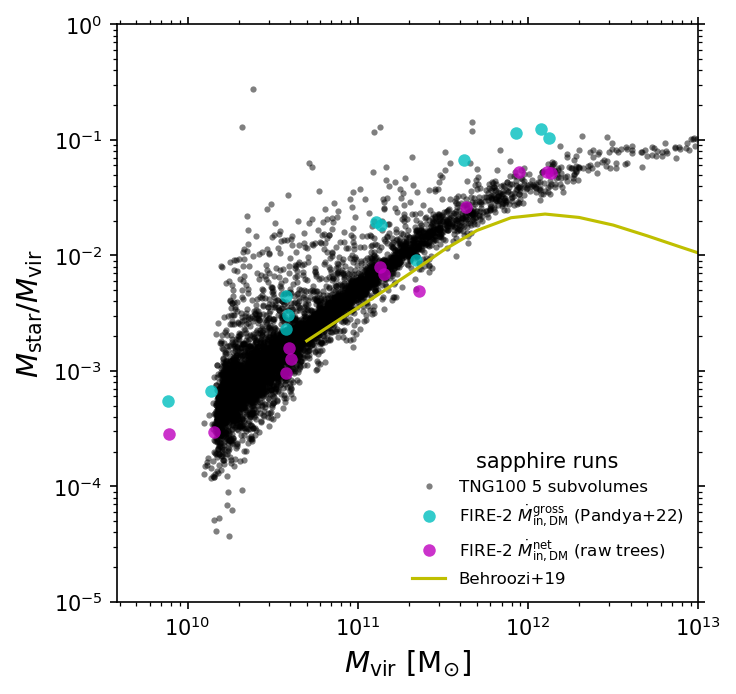

In [3]:
from astropy.table import Table
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

### overplot z=0 SMHM relation with individual FIRE points from both sets of runs (gross and net DM accretion rate)

# first collect z=0 (Mstar,Mvir) tuple for every object 

smhm_pandya22 = np.array([(d['M_star'][-1],d['Mvir'][-1]) for d in results_pandya22.values()])

smhm_fire2 = np.array([(d['M_star'][-1],d['Mvir'][-1]) for d in results_fire2.values()])

smhm_tng = np.array([(d['M_star'][-1],d['Mvir'][-1]) for d in results_tng_filtered.values()])


# now plot

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)

ax.plot(smhm_tng[:,1],smhm_tng[:,0] / smhm_tng[:,1],'k.',alpha=0.5,mec='none',label='TNG100 5 subvolumes')

ax.plot(smhm_pandya22[:,1],smhm_pandya22[:,0] / smhm_pandya22[:,1],'co',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm gross}$ (Pandya+22)')

ax.plot(smhm_fire2[:,1],smhm_fire2[:,0] / smhm_fire2[:,1],'mo',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm net}$ (raw trees)')

# read in Behroozi+19 UniverseMachine DR1 Median SMHM relation  (discard below logmvir<10.5 due to Bolshoi-Planck incompleteness)
tum = Table.read('/mnt/ceph/users/vpandya/umachine-dr1/data/smhm/median_raw/smhm_a1.002312.dat',format='ascii')
tum = tum[tum['HM(0)']>10.5]
ax.plot(10**tum['HM(0)'],10**tum['Med_All(1)'],c='y',ls='-',label='Behroozi+19')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(None,1e13)
ax.set_ylim(1e-5,1e0)

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0,title='sapphire runs')

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$]',fontsize=14)
ax.set_ylabel(r'$M_{\rm star}/M_{\rm vir}$',fontsize=14)


Text(0, 0.5, '$Z_{\\rm ISM}/Z_{\\odot}$')

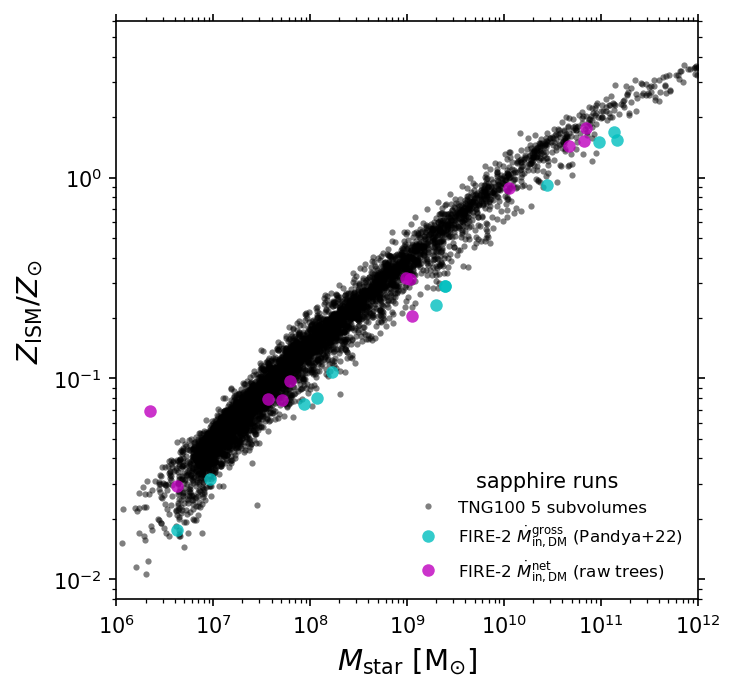

In [4]:
# now plot the z=0 gas MZR 

# first collect z=0 (Mstar,Zism) tuple for every object 

mzr_pandya22 = np.array([(d['M_star'][-1],d['MZ_ism'][-1] / d['M_ism'][-1] / 0.02) for d in results_pandya22.values()])

mzr_fire2 = np.array([(d['M_star'][-1],d['MZ_ism'][-1] / d['M_ism'][-1] / 0.02) for d in results_fire2.values()])


mzr_tng = np.array([(d['M_star'][-1],d['MZ_ism'][-1] / d['M_ism'][-1] / 0.02) for d in results_tng_filtered.values()])


# now plot

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)

ax.plot(mzr_tng[:,0],mzr_tng[:,1],'k.',alpha=0.5,mec='none',label='TNG100 5 subvolumes')

ax.plot(mzr_pandya22[:,0],mzr_pandya22[:,1],'co',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm gross}$ (Pandya+22)')

ax.plot(mzr_fire2[:,0],mzr_fire2[:,1],'mo',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm net}$ (raw trees)')




ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e6,1e12)
ax.set_ylim(8e-3,6e0)

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0,title='sapphire runs')

ax.set_xlabel(r'$M_{\rm star}$ [M$_{\odot}$]',fontsize=14)
ax.set_ylabel(r'$Z_{\rm ISM}/Z_{\odot}$',fontsize=14)


In [49]:
test_vals = np.array([(d['M_star'][np.argmin(np.abs(np.array(d['redshift'])-0.7))],
                    d['MZ_ism'][np.argmin(np.abs(np.array(d['redshift'])-0.7))] / d['M_ism'][np.argmin(np.abs(np.array(d['redshift'])-0.7))] / 0.02,
                    d['redshift'][np.argmin(np.abs(np.array(d['redshift'])-0.7))]) for d in results_tng_filtered.values()
                    if np.abs(d['redshift'][np.argmin(np.abs(np.array(d['redshift'])-0.7))]-0.7) < 0.03])

In [28]:
test_vals

array([[1.00000000e+00, 1.00000000e-04, 7.00576401e+00],
       [4.92615946e+05, 2.12960273e-02, 7.49114518e+00],
       [1.06800712e+06, 1.90458216e-02, 7.47185857e+00],
       ...,
       [1.16395003e+05, 1.58139002e-02, 7.54083035e+00],
       [4.64145880e+03, 6.78819688e-03, 7.54797040e+00],
       [1.00000000e+00, 1.00000000e-04, 7.23655415e+00]])

In [31]:
test_z75 = np.where(np.abs(test_vals[:,2] - 7.5) < 0.03)

In [47]:
test_vals[test_z75].shape

(2694, 3)

In [50]:
test_vals.shape

(6455, 3)

In [ ]:
np.argmin(np.abs(np.array(d['redshift'])-7.5))

In [22]:
np.argmin(np.abs(np.array(d['redshift'])-7.5))

0

In [56]:
bins_mstar = np.logspace(6,12,25)

In [51]:
test_vals

array([[2.77672206e+06, 2.21192887e-02, 6.99622966e-01],
       [5.91172360e+07, 1.24714514e-01, 6.99245950e-01],
       [1.71509951e+08, 2.01340385e-01, 6.99087331e-01],
       ...,
       [1.00405994e+07, 5.48462315e-02, 6.99891036e-01],
       [7.42317001e+06, 5.21229737e-02, 6.98895478e-01],
       [1.05663813e+07, 6.30184610e-02, 7.00102444e-01]])

In [ ]:
[np.median(test_vals[() & ()])]

In [64]:
[np.median(test_vals[(test_vals[:,0]>bins_mstar[mmin]) & (test_vals[:,0]<bins_mstar[mmin+1])][:,1]) for mmin in range(len(bins_mstar)) if mmin < len(bins_mstar)-1]

[0.02238066613871129,
 0.02662513516088045,
 0.0338567937859333,
 0.04449281716129067,
 0.05866357549706261,
 0.07509104057985512,
 0.09465774967533505,
 0.12103860133751097,
 0.14890144431860786,
 0.18149531995285104,
 0.2289754977171103,
 0.2793493598802315,
 0.35150588600066557,
 0.4270870736713669,
 0.5212720262761754,
 0.631078867837115,
 0.7956034337278434,
 1.0180200136499427,
 1.2822047649186568,
 1.4332616335178825,
 1.852038628158938,
 2.0078831431301247,
 2.291819420527065,
 2.568457380066114]

In [59]:
np.arange(len(bins_mstar))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

In [63]:
24 < len(bins_mstar)

True

In [70]:
(bins_mstar[:-1] + bins_mstar[1:])/2.

array([1.38913971e+06, 2.47027854e+06, 4.39284546e+06, 7.81170663e+06,
       1.38913971e+07, 2.47027854e+07, 4.39284546e+07, 7.81170663e+07,
       1.38913971e+08, 2.47027854e+08, 4.39284546e+08, 7.81170663e+08,
       1.38913971e+09, 2.47027854e+09, 4.39284546e+09, 7.81170663e+09,
       1.38913971e+10, 2.47027854e+10, 4.39284546e+10, 7.81170663e+10,
       1.38913971e+11, 2.47027854e+11, 4.39284546e+11, 7.81170663e+11])

In [66]:
bins_mstar

array([1.00000000e+06, 1.77827941e+06, 3.16227766e+06, 5.62341325e+06,
       1.00000000e+07, 1.77827941e+07, 3.16227766e+07, 5.62341325e+07,
       1.00000000e+08, 1.77827941e+08, 3.16227766e+08, 5.62341325e+08,
       1.00000000e+09, 1.77827941e+09, 3.16227766e+09, 5.62341325e+09,
       1.00000000e+10, 1.77827941e+10, 3.16227766e+10, 5.62341325e+10,
       1.00000000e+11, 1.77827941e+11, 3.16227766e+11, 5.62341325e+11,
       1.00000000e+12])

In [74]:
(3.16227766e+06+5.62341325e+06)/2.

4392845.455

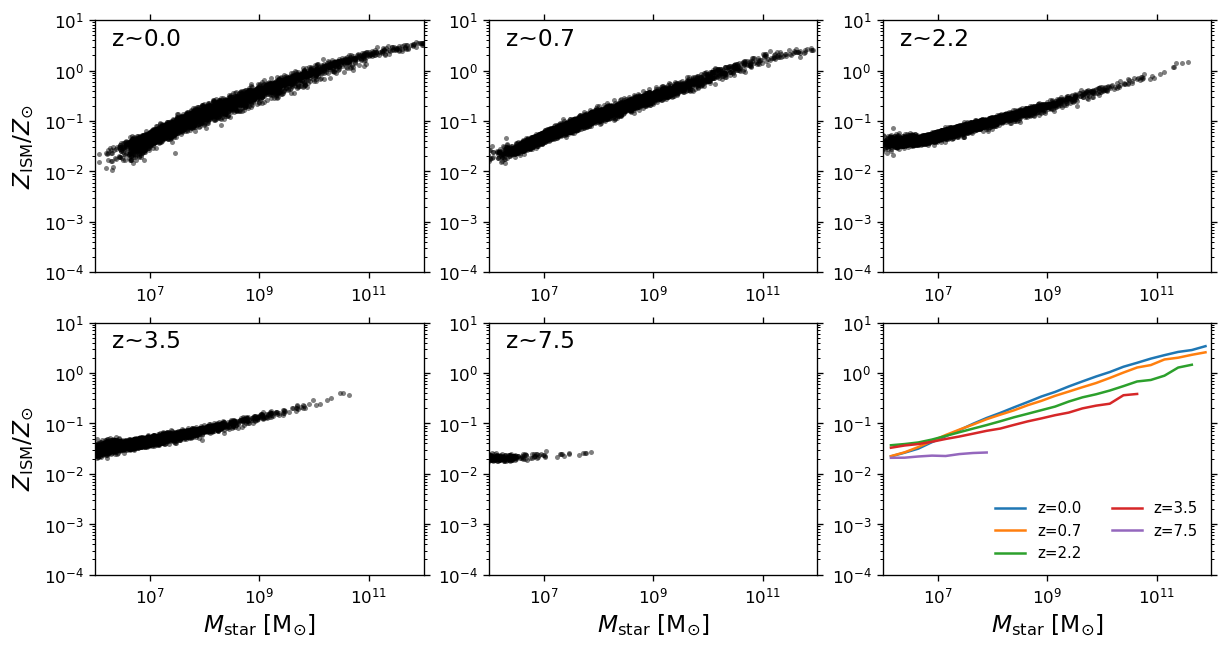

In [77]:
# now plot the median relations at roughly z=7.5, z=3.5, z=2.2, z=0.7, z=0.0 using the TNG-sapphire run

fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(12,6),dpi=120)
allax = np.ravel(axes)

# list of redshifts
zlist = [0.0,0.7,2.2,3.5,7.5]
zthresh = 0.03 # will include objects that fall 

# pre-defined mstar bins to compute median MZR at each redshift
bins_mstar = np.logspace(6,12,25)
bincenters_mstar = (bins_mstar[:-1] + bins_mstar[1:])/2.

# loop over lists
for znum,zval in enumerate(zlist):
    
    # use a dict comprehension to store list of (Mstar,Zism,redshift) tuples for all objects in catalog close to current redshift
    mzr_z = np.array([(d['M_star'][np.argmin(np.abs(np.array(d['redshift'])-zval))],
                       d['MZ_ism'][np.argmin(np.abs(np.array(d['redshift'])-zval))] / d['M_ism'][np.argmin(np.abs(np.array(d['redshift'])-zval))] / 0.02,
                       d['redshift'][np.argmin(np.abs(np.array(d['redshift'])-zval))]) for d in results_tng_filtered.values()
                       if np.abs(d['redshift'][np.argmin(np.abs(np.array(d['redshift'])-zval))]-zval) < 0.03])
    
    # scatterplot for this redshift
    allax[znum].plot(mzr_z[:,0],mzr_z[:,1],'k.',alpha=0.5,mec='none')
    
    # label redshift
    allax[znum].text(0.05,0.9,'z~%s'%zval,transform=allax[znum].transAxes,fontsize=14)
    
    # use list comprehension to store median Zism in mstar bins for this redshift
    medians_znow = [np.median(mzr_z[(mzr_z[:,0]>bins_mstar[mmin]) & (mzr_z[:,0]<bins_mstar[mmin+1])][:,1]) 
                    for mmin in range(len(bins_mstar)) if mmin < len(bins_mstar)-1]
    
    # overplot in bottom right panel
    allax[5].plot(bincenters_mstar,medians_znow,label='z=%s'%zval)
    
# axis limits and labels
for ax in allax:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e6,1e12)
    ax.set_ylim(1e-4,1e1)
    
axes[0][0].set_ylabel(r'$Z_{\rm ISM}/Z_{\odot}$',fontsize=14)
axes[1][0].set_ylabel(r'$Z_{\rm ISM}/Z_{\odot}$',fontsize=14)

for axcol in [0,1,2]:
    axes[1][axcol].set_xlabel(r'$M_{\rm star}$ [M$_{\odot}$]',fontsize=14)

    
# legend in bottom right
allax[5].legend(loc='lower right',fontsize=9,ncol=2,fancybox=True,framealpha=0)

In [ ]:
# finally let's also overplot time series of some key properties 
# for each fire halo, we'll get 5 random TNG halos with similar Mvir(z=0) for comparison

